In [5]:
import os
os.chdir('/Users/ruhil/health-risk-predictor')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

# First Look
print(df.shape)
df.head()
print(df.info())
print(df.describe())

(253680, 22)
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15

In [8]:
print(df['Diabetes_012'].value_counts())
print(df['Diabetes_012'].unique())

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
[0. 2. 1.]


In [11]:
print(df['Diabetes_012'].value_counts())


Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [12]:
df['Diabetes_binary'] = df['Diabetes_012'].apply(lambda x:0 if x ==0 else 1)

In [13]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0    213703
1     39977
Name: count, dtype: int64

In [16]:
correlation = df.corr()['Diabetes_binary'].sort_values(ascending=False)
correlation

Diabetes_binary         1.000000
Diabetes_012            0.983304
GenHlth                 0.300785
HighBP                  0.270334
BMI                     0.223851
DiffWalk                0.222155
HighChol                0.210290
Age                     0.185891
HeartDiseaseorAttack    0.176933
PhysHlth                0.174948
Stroke                  0.104800
MentHlth                0.074971
CholCheck               0.067879
Smoker                  0.062778
NoDocbcCost             0.038025
Sex                     0.029606
AnyHealthcare           0.014079
Fruits                 -0.042088
HvyAlcoholConsump      -0.056682
Veggies                -0.059219
PhysActivity           -0.121392
Education              -0.131803
Income                 -0.172794
Name: Diabetes_binary, dtype: float64

/var/folders/3l/1_q7gwgn3ql9_hjs9p1byk280000gn/T/ipykernel_11999/1259011892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary',data = df, palette='Set2')


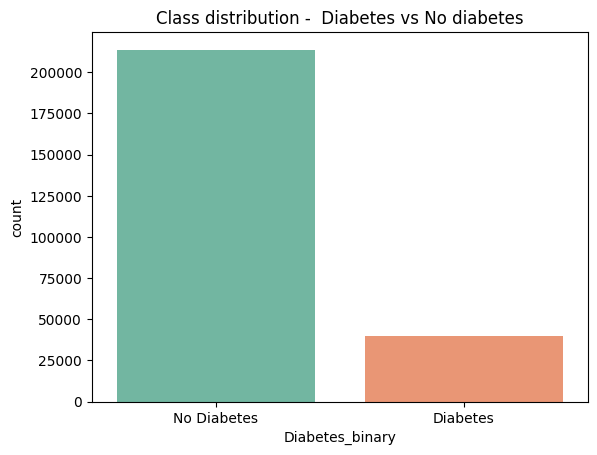

/var/folders/3l/1_q7gwgn3ql9_hjs9p1byk280000gn/T/ipykernel_11999/1259011892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x ='Diabetes_binary', y='BMI',data =df, palette='coolwarm')


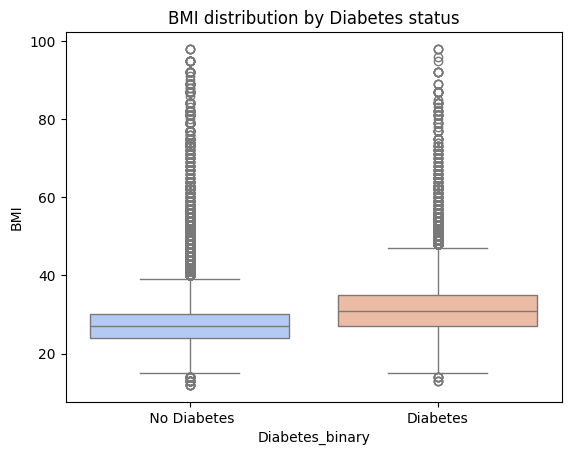

In [17]:
# Plot 1 Class Imbalance
plt.Figure(figsize=(8,5))
sns.countplot(x='Diabetes_binary',data = df, palette='Set2')
plt.title('Class distribution -  Diabetes vs No diabetes')
plt.xticks([0,1],['No Diabetes','Diabetes'])
plt.savefig('class_distribution.png')
plt.show()

# Plot 2 - BMI vs Diabetes

plt.Figure(figsize=(8,5))
sns.boxplot(x ='Diabetes_binary', y='BMI',data =df, palette='coolwarm')
plt.title('BMI distribution by Diabetes status')
plt.xticks([0,1],[' No Diabetes','Diabetes'])
plt.savefig('bmi_daibetes.png')
plt.show()

In [ ]:
# Model Training
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# define Features and target 
X = df.drop(['Daibetes_binary','Diabetes_012'], axis =1)
y = df['Daibetes_binary']

# Split first Before aplying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2 , random_state=42)

# Applying SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

# Check balance after SMOTE
print("Before Smote",y_train.value_counts(),to_dict())
print("After Smote",y_train_sm.value_counts(),to_dict())